# **Introduction to Neural Network Quantum States**
---

This notebook serves as an introduction to the use of neural networks in solving the quantum many-body problem. In particular, it briefly discusses the underlying physics, math, and computational concepts and explores how to implement them with the NetKet library, both in **Ground State Search** and **Time Evolution**.






## **The Physics**
The *Many-Body Problem*, a well-known problem, seeks to describe the behavior of a system of particles under the laws of physics. Here, we explore the *Quantum Many-Body Problem*. That is, the problem of describing the behavior of many-body systems under the laws of quantum mechanics.


### **The Wavefunction and Quantum States**

Quantum physics is fundamentally probabilistic. Instead of being definite objects, particles are  described by wavefunctions. This is not to say that they are physically waves, rather that the state of any particle is accurately modeled using a **wavefunction**. This is encoded in the time-dependent **Schrödinger equation**:

$$i\hbar \frac{\partial}{\partial t}|\psi(t) \rangle = H|\psi(t) \rangle$$

Here, ${H}$ is the Hamiltonian (the total energy stored in a system), $\psi(t)$ is the system's **wavefunction**, $|\psi \rangle$ is a [ket](https://en.wikipedia.org/wiki/Bra%E2%80%93ket_notation) representing a quantum state vector, $i = \sqrt{-1}$ is the imaginary unit, and $\hbar$ is the reduced Planck's constant.

There is also a time-independent version of the Schrödinger equation, also known as its eigenvalue form or the eigenequation:

$$H|\psi \rangle  = E |\psi \rangle$$

where $E$ represents the system's energy eigenvalues. Put simply, these energy eigenvalues are the allowed discrete energy levels for a system, where $E_0$ corresponds to the lowest of these values, referred to as the ground state energy.

Every state vector lives in a Hilbert space containing all the possible states of a system. For a discrete system of $N$ spin-$1/2$ particles, the Hilbert space has dimensions $2^N$, which means it is spanned by $2^N$ base states. Any state in that space then exists in a **superposition** of these base states. This superposition is  a linear combination given by

$$
  | \psi \rangle = \sum_{i=1}^{2^N} c_i | \psi_i \rangle = c_1| \psi_1 \rangle + c_2| \psi_2 \rangle + \dots +c_{2^N}| \psi_{2^N} \rangle
$$

where $| \psi_i \rangle$ is the $i$-th base state orthonormal to the rest and $c_i$ is a complex coefficient that satisfies normalization (i.e. $\sum |c_i|^2 = 1$).



### **Transverse Field Ising Model**

We begin with the Ising Model. Classically, the Ising Model describes a system of sites with discrete spin variables of either $1$ or $-1$ (spin up and spin down). This model has the Hamiltonian

$$
  H = -J\sum_{\langle i , j \rangle}\sigma_i\sigma_j
$$

where $J$ represents the strength of coupling between spins.

To describe the system quantum mechanically, we introduce an external field along a transverse axis, leading to the possibility of spin flips. This gives us the **Transverse Field Ising Model (TFIM)**, with the Hamiltonian

$$
H = -J\sum_{\langle i , j \rangle}\sigma^z_i\sigma^z_j - h\sum_{i}\sigma^x_i
$$

where $h$ represents the strength of the transverse field and $\sigma^{\alpha}$ is a spin operator for the $\alpha$ direction. These spin operators are represented by the Pauli matrices

$$
\sigma_x = \begin{bmatrix} 0 & 1 \\ 1 & 0\end{bmatrix},
\sigma_y = \begin{bmatrix} 0 & -i \\ i & 0\end{bmatrix},
\sigma_z = \begin{bmatrix} 1 & 0 \\ 0 & -1\end{bmatrix}.
$$

$\sigma^{\alpha}_i$ represents the $\sigma^{\alpha}$ acting solely on the $i$-th site. This can be written as a tensor product with the identity matrix leaving other spins unchanged.

$$
 \sigma^{\alpha}_i = I \otimes I \otimes  \dots \otimes I \otimes \sigma^{\alpha} \otimes I \otimes \dots \otimes I
$$



### **An Example Problem**
Let us consider the simplest problem of trying to find the ground state energy for a two-particle TFIM under open boundary conditions. A system of two particles will have $2^2$ base states, which we can write as

$$(\uparrow \uparrow), (\uparrow \downarrow), (\downarrow \uparrow), (\downarrow \downarrow).$$

Under TFIM, the Hamiltonian for this system is

$$
   H = -J\sum_{i,j}\sigma^z_i\sigma^z_j - h\sum_{i}\sigma^x_i.
$$

With only two particles, this is simply

$$
   H = -J\sigma^z_1\sigma^z_2 - h(\sigma^x_1 + \sigma^x_2),
$$

For our case of two particles,
$$
    \sigma^z_1 = \sigma_z \otimes I = \begin{bmatrix} 1 & 0 \\ 0 & -1\end{bmatrix} \otimes \begin{bmatrix} 1 & 0 \\ 0 & 1\end{bmatrix}
    = \begin{bmatrix} 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & -1 & 0 \\ 0 & 0 & 0 & -1 \end{bmatrix}
$$

$$
    \sigma^z_2 = I  \otimes \sigma_z = \begin{bmatrix} 1 & 0 \\ 0 & 1\end{bmatrix} \otimes \begin{bmatrix} 1 & 0 \\ 0 & -1\end{bmatrix}
    = \begin{bmatrix} 1 & 0 & 0 & 0 \\ 0 & -1 & 0 & 0 \\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & -1 \end{bmatrix}
$$
$$
    \sigma^x_1 = \sigma_x \otimes I = \begin{bmatrix} 0 & 1 \\ 1 & 0\end{bmatrix} \otimes \begin{bmatrix} 1 & 0 \\ 0 & 1\end{bmatrix}
    = \begin{bmatrix} 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1 \\ 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \end{bmatrix}
$$

$$
    \sigma^x_2 = I  \otimes \sigma_x = \begin{bmatrix} 1 & 0 \\ 0 & 1\end{bmatrix} \otimes \begin{bmatrix} 0 & 1 \\ 1 & 0\end{bmatrix}
    = \begin{bmatrix} 0 & 1 & 0 & 0 \\ 1 & 0 & 0 & 0 \\ 0 & 0 & 0 & 1 \\ 0 & 0 & 1 & 0 \end{bmatrix}
$$

The Hamiltonian yields

$$
\begin{align*}
   H &= -J\sigma^z_1\sigma^z_2 - h(\sigma^x_1 + \sigma^x_2) \\
   &= -J \begin{bmatrix} 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & -1 & 0 \\ 0 & 0 & 0 & -1 \end{bmatrix} \begin{bmatrix} 1 & 0 & 0 & 0 \\ 0 & -1 & 0 & 0 \\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & -1 \end{bmatrix}
   + -h\left( \begin{bmatrix} 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1 \\ 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \end{bmatrix} + \begin{bmatrix} 0 & 1 & 0 & 0 \\ 1 & 0 & 0 & 0 \\ 0 & 0 & 0 & 1 \\ 0 & 0 & 1 & 0 \end{bmatrix} \right) \\
   &= \begin{bmatrix} -J & 0 & 0 & 0 \\ 0 & J & 0 & 0 \\ 0 & 0 & J & 0 \\ 0 & 0 & 0 & -J \end{bmatrix} + \begin{bmatrix} 0 & -h & -h & 0 \\ -h & 0 & 0 & -h \\ -h & 0 & 0 & -h \\ 0 & -h & -h & 0 \end{bmatrix} \\
   &= \begin{bmatrix} -J & -h & -h & 0 \\ -h & J & 0 & -h \\ -h & 0 & J & -h \\ 0 & -h & -h & -J \end{bmatrix}
\end{align*}
$$

To find the exact ground state energy, we can make use of the time-independent Schrödinger's equation.
$$
  \begin{align*}
    H\left| \psi \right\rangle &= E \left| \psi \right\rangle \\
    \begin{bmatrix} -J & -h & -h & 0 \\ -h & J & 0 & -h \\ -h & 0 & J & -h \\ 0 & -h & -h & -J \end{bmatrix}  \begin{bmatrix} c_1 \\ c_2 \\c_3 \\c_4  \end{bmatrix}
    &=  (E\cdot I) \begin{bmatrix} c_1 \\ c_2 \\c_3 \\c_4  \end{bmatrix}
    \\
    \begin{bmatrix} -J-E & -h & -h & 0 \\ -h & J-E & 0 & -h \\ -h & 0 & J-E & -h \\ 0 & -h & -h & -J-E \end{bmatrix}  \begin{bmatrix} c_1 \\ c_2 \\c_3 \\c_4  \end{bmatrix}
    &=  0
    \\
  \end{align*}
$$
This implies that
$$
  \begin{align*}
    \det \begin{pmatrix} -J-E & -h & -h & 0 \\ -h & J-E & 0 & -h \\ -h & 0 & J-E & -h \\ 0 & -h & -h & -J-E \end{pmatrix}  
    &=  0
    \\
  \end{align*}
$$
So, we solve for this determinant as we would any determinant. Doing so leads to these combined equations

$$
\begin{align*}
  (J^2-E^2)\left(J^2 - E^2 + 2h^2\right) - -h^2(J^2-E^2) + h^2(J^2-E^2) &= 0
  \\
  (J^2-E^2)\left(J^2 - E^2 + 2h^2\right) + 2h^2(J^2-E^2) &= 0
  \\
  (J^2-E^2)(J^2 - E^2 + 4h^2) &= 0
\end{align*}
$$
So, we have our solutions
$$
\begin{align*}
  E^2 = J^2 => E = \pm J \\
  E^2 = J^2 + 4h^2 => E = \pm \sqrt{J^2 + 4h^2}
\end{align*}
$$
This gives our lowest energy eigenvalue, and thus our ground state energy as
$$
  E_0 = -\sqrt{J^2 + 4h^2}
$$



#### **What's the Problem?**
It should be clear going through this problem that solving the ground state for an even larger system of problems will involve exponentially more calculations. For a quantum system, the Hilbert space grows exponentially, so we reframe the problem, turning to numerical methods.

### **Ansatz**
Bound by limitations in computational complexity, we make use of variational **ansatz**, which are essentially trial wavefunctions  that we can optimize as we solve the problem. Essentially, they are *trial solutions* or starting points whose parameters can be updated.  

### **Ground State Search**

To apply this to a problem, we can begin with the expectation value of the energy $E$,

$$
E[\psi] = \frac{\langle \psi |H| \psi \rangle}{\langle \psi | \psi \rangle} \geq E_0,
$$

where $E_0$ is the ground state energy.

It is clear that we can treat the ground state search as an **optimization** problem, adjusting the parameters of our neural network to minimize the energy eigenvalue. While this is still challenging to solve analytically in higher dimensions, we can approach this problem stochastically instead.

### **Variational Monte Carlo**

Considering the quantum expectation value of energy $E$ as above, using the closure relation, $\sum_x |x \rangle \langle x |$ , to write:

\begin{align*}
\frac{\langle \psi |H| \psi \rangle}{\langle \psi | \psi \rangle} &= \frac{\sum_{x,x'}\langle\psi|x\rangle \langle x|H|x'\rangle\langle x'|\psi\rangle}{\sum_x \langle\psi|x\rangle \langle x|\psi\rangle}
\\
&= \frac{\sum_{x,x'}\psi^{*}(x) \, \langle x|H|x'\rangle \, \psi(x')}{\sum_x|\psi(x)|^2}
\\
&= \frac{\sum_{x,x'}\psi^{*}(x) \, H_{x,x'} \, \psi(x') \frac{\psi(x)}{\psi(x)}}{\sum_x|\psi(x)|^2}
\\
&= \frac{\sum_x|\psi(x)|^2\, \sum_{x'}H_{x,x'} \, \frac{\psi(x')}{\psi(x)}}{\sum_x|\psi(x)|^2}
\end{align*}

We define our *local energy* to be $E_{loc} = \sum_{x'}H_{x,x'} \, \frac{\psi(x')}{\psi(x)}$, such that $\frac{\sum_x|\psi(x)|^2 \, E_{loc}}{\sum_x|\psi(x)|^2}$ is simply taking the **statistical** average of our local energy over the probability distribition $|\psi(x)|^2$ which we can denote as $E = \langle \langle E_{loc} \rangle \rangle$. Note that this differs from the **quantum** expectation value $\langle E_{loc} \rangle $

So, instead of computing through the entire space, we optimize the ansatz via randomly-selected states sampled according to our probability distribution.

This is the method of the Variational Monte Carlo (VMC), summarized in these steps:
1. A state is **sampled** according to the distribution defined by the current ansatz' parameters
2. The **local energy** is computed, with the average over all sampled states giving the an estimate for the energy
3. The **gradient** of this expectation value is computed with respect to our current parameters
4. Some optimization step is performed to lower the energy estimate
5. New parameters for the neural network are computed based on this optimization and the previous parameters

Repeating this process a large number of times is what allows us to tune the parameters of our ansatz to represent a target state. The particular algorithms for sampling and optimizing will be explored more deeply as we go through the coding sections of this notebook.

#### **Zero-Variance Property**

Another key feature of the stochastic approach to the search for any particular quantum state is the so-called **Zero-Variance Property**. Consider the variance of our local energy:

$$
\begin{align*}
\text{var}(E_{loc}) &= \langle E^2_{loc}\rangle - \langle E_{loc} \rangle^2
\\
&= \sum_x  \psi(x)^2 E^2_{loc} - \langle H\rangle^2
\\
&= \sum_x  \psi(x)^2 \left(\sum_{x_1}H_{x,x_1} \, \frac{\psi(x_1)}{\psi(x)}\right)\left(\sum_{x_2}H_{x,x_2} \, \frac{\psi(x_2)}{\psi(x)}\right) - \langle H\rangle^2
\\
&= \sum_x \left(\sum_{x_1}H_{x,x_1} \psi(x_1)  \,\right)\left(\sum_{x_2}H_{x,x_2} \psi(x_2)  \,\right) - \langle H\rangle^2
\\
&=  \sum_{x_1} \psi(x_1) \sum_x H_{x,x_1} \sum_{x_2}H_{x,x_2} \psi(x_2) - \langle H\rangle^2
\\
&=  \sum_{x_1,x_2} \psi(x_1) (H^2)_{x_1,x_2} \psi(x_2) - \langle H\rangle^2
\\
&=  \langle H^2 \rangle - \langle H\rangle^2
\end{align*}
$$

Now, assume we are in some energy eigenstate of a system. Thus,
$$
\begin{align*}
H\psi &= E\psi
\\
\sum_{x'}H_{x,x'}\,\psi(x') &= E\,\psi(x)
\end{align*}
$$

Now, consider our local energy

$$
\begin{align*}
E_{loc} &= \sum_{x'}H_{x,x'} \, \frac{\psi(x')}{\psi(x)}
\\
&= \frac{1}{\psi(x)}\sum_{x'}H_{x,x'} \, \psi(x')
\\
&= \frac{1}{\psi(x)}E\,\psi(x) = E
\end{align*}
$$

So, for all $x$, the local energy is simply $E$. This implies that $\langle H^2 \rangle = \langle H \rangle^2 = E^2$ in an eigenstate.

Thus, we observe that in an exact eigenstate, the energy variance must vanish. This makes it easy to check whether our optimization method actually moves our ansatz closer to an exact solution.

### **Neural Networks**
When it comes to selecting particular ansatz, conventional choices include the Mean-Field or the Jastrow. However, in this notebook, we introduce **Neural Network Quantum States** (NQS).

Neural networks are a powerful tool for many-body quantum physics, as they can reduce the amount of data to be stored and can be optimized with known techniques. Mathematically, they can be thought of as a method of representing high-dimensional functions.  Because of this, we can use a neural network to represent the wavefunction $\psi$ for a many-body system using a set of parameters. In particular, we use

$$ \ln(\psi(x)) = F(x; p_1, p_2, ... p_{N_p}) $$

where $F$ is the output of a neural network, dependent on a set of parameters $p$. It is of note that we use the neural network as the $\ln$ of the wavefunction. This is done both because the probability amplitudes of quantum states can differ greatly and because it simplifies some gradient calculations.

In addition, all of our parameters $p$ are said to live in the **parameter space**. This space is modelled as some higher dimensional manifold, where a point in this space is some set of parameters. Knowing the geometry of this space, helps us to develop more precise algorithms for optimizing our wavefunction.

## **A Simple Ground State Search**

We introduce the application of these techniques to the simplest problem of two particles under TFIM. We do this, both to understand the code, and to show that the method works. Doing so for a two-particle-system offers no computational advantage, but it is a clear demonstration of how to translate the physics into code and vice versa.

The code here is used and modified from the Ising Model (Vicentini, 2021), Heisenberg Model (Carleo & Vicentini, n.d.) [NetKet tutorials](https://netket.readthedocs.io/en/latest/tutorials/index.html), and a separate tutorial w/added dynamics (Vicentini, n.d.).

### **Installation**
To begin with, NetKet is an open-source Python library built specifically for machine learning in quantum physics. One can find all the documentation and many, many more tutorials [here](https://netket.readthedocs.io/en/stable/index.html). This tutorial is based on the first NetKet tutorial, but it also introduces other concepts later on.




In [ ]:
%pip install --quiet netket

In [ ]:
!python --version


Python 3.12.12


In [ ]:
%%python -c "import netket; print(netket.__version__)"

3.20.4.dev6+g6fb0e3cfb


In [ ]:
%%python -c "import jax; print(jax.__version__)"

0.7.2


In [ ]:
import os

os.environ["JAX_PLATFORM_NAME"] = "gpu"

In [ ]:
import jax
print(jax.default_backend())

gpu


### **Defining the Hamiltonian**

In [ ]:
import numpy as np
import netket as nk
import jax

# We begin with the two-particle TFIM system
N = 2

# This defines our Hilbert space
hilbert = nk.hilbert.Spin(s=1 / 2, N=N)
print("Complete Hilbert Space: \n", hilbert.all_states(), '\n')

# NetKet is also able to directly generate random states from the Hilbert space
print("Randomly Generated States from the Hilbert Space:")
hilbert.random_state(jax.random.key(0), 4)

Complete Hilbert Space: 
 [[ 1  1]
 [ 1 -1]
 [-1  1]
 [-1 -1]] 

Randomly Generated States from the Hilbert Space:


Array([[-1, -1],
       [-1, -1],
       [-1, -1],
       [ 1,  1]], dtype=int8)

In [ ]:
from math import sqrt
sigmax = nk.operator.spin.sigmax
sigmaz = nk.operator.spin.sigmaz

# Set arbitrary constants for J and h for now
J = 2
h = 1

# Define the Hamiltonian according to the TFIM
H = -J*sum([sigmaz(hilbert, i) @ sigmaz(hilbert, (i + 1)) for i in range(N-1)]) - h*sum([sigmax(hilbert, i) for i in range(N)])

H_matrix = H.to_dense()

# Utilize numpy functions to find the eigenvalues
evals, evecs = np.linalg.eigh(H_matrix)
E0 = evals[0]

print("Hamiltonian:\n", H_matrix)
print("Energy Eigenvalues: ", evals)
print("Ground State Energy: ",E0)

# To compare this with the ground state energy we found analytically:
print("Our Analytical Solution: ", -sqrt(J**2 + 4*(h**2)))

Hamiltonian:
 [[-2. -1. -1.  0.]
 [-1.  2.  0. -1.]
 [-1.  0.  2. -1.]
 [ 0. -1. -1. -2.]]
Energy Eigenvalues:  [-2.82842712 -2.          2.          2.82842712]
Ground State Energy:  -2.82842712474619
Our Analytical Solution:  -2.8284271247461903


### **Sampling and Metropolis-Hastings algorithm**
To appropriately sample states from our Hilbert space, we make use of the **Metropolis-Hastings algorithm**.

The algorithm works by arbitrarily selecting an initial state $s$, the next state $s'$ is then *proposed* via a *transition rule*. Following this transition rule, the proposed state is accepted with the following probability ([from NetKet documentation](https://github.com/netket/netket/blob/main/netket/sampler/metropolis.py))

$$
A(s \rightarrow s^\prime) = \mathrm{min} \left( 1,\frac{P(s^\prime)}{P(s)} e^{L(s,s^\prime)} \right) ,
$$

where the probability that is sampled from is $P(s)=|M(s)|^p$, $M(s)$ is a function (called the Machine), $p$ is a parameter we define, and $L(s,s')$ is some correcting factor.


#### **Metropolis Local Sampling**
In our case, we make use of the local rule for sampling. This rule acts on only one local degree of freedom (our spin in this case). In very simple terms, it takes the existing state, selects a spin to flip, then proposes that state, to be accepted with the probability as outlined above.  

In [ ]:
sampler = nk.sampler.MetropolisLocal(hilbert)

### **Neural Network Quantum State**

Under the classification of **neural networks**, there are many types of machines that can be used for the purpose of representing the wavefunction. These differing machines typically vary by their architecture, featuring different combinations and types of layers. Some of these include **Feed Forward Neural Networks (FFNN)**, **Restricted Boltzmann Machines (RBM)**, and **Transformers**, among others.

In this tutorial, we begin with one of the simplest neural networks, the FFNN with only two layers, an input and an activation layer.

In [ ]:
'''
[NetKet Documentation Comment]
Numerical operations in the NetKet model should always use jax.numpy instead of numpy because jax supports computing derivatives.
If you want to better understand the difference between the two, check https://flax.readthedocs.io/en/latest/notebooks/jax_for_the_impatient.html
'''

import jax.numpy as jnp

'''
[NetKet Documentation Comment]
Flax is a framework to define models using jax
Flax has two 'neural network' libraries. THe  first one is `flax.linen` which has been in use since 2020, and most examples use it.
The new one, nnx, is somewhat simpler to use, and it's the one we will use here.
'''

from flax import nnx

class FFNN(nnx.Module):

    def __init__(self, N: int, alpha: int = 1, *, rngs: nnx.Rngs):

        """
        [NetKet Tutorial Comment]
        Construct a Feed-Forward Neural Network with a single hidden layer.

        Args:
            N: The number of input nodes (number of spins in the chain).
            alpha: The density of the hidden layer. The hidden layer will have N*alpha nodes.
            rngs: The random number generator seed.
        """

        self.alpha = alpha

        # We define a linear layer with output nodes = `alpha` times the number of input nodes

        self.linear = nnx.Linear(in_features=N, out_features=alpha * N, rngs=rngs)

    def __call__(self, x: jax.Array):

        # We first pass the input to our linear layer
        y = self.linear(x)

        # Then our activation function is simply a ReLu (Rectified Linear unit)
        y = nnx.relu(y)

        # Sums the output because we require a scalar output (ln(psi))
        return jnp.sum(y, axis=-1)


model = FFNN(N=N, alpha=1, rngs=nnx.Rngs(2))

# Defining our variational state
vstate = nk.vqs.MCState(sampler, model, n_samples=2000)

### **Variational Monte Carlo**
One can write their own optimization loop or make use of NetKet's built-in framework. We first show how one would write the code for themselves to get a better understanding of the iterative optimization process.


#### **Stochastic Gradient Descent**
The most commonly used optimization scheme in neural networks is **stochastic gradient descent**. This method considers our parameters $p$ and updates them according to

$$
p_{i+1} = p_i - \eta \nabla_p \langle H\rangle .
$$

where $\eta$ is our learning rate and $\nabla_p \langle H\rangle$ is our gradient. This gradient is typically estimated, based on our sample state, as

$$
\nabla_p \langle H\rangle = 2 \text{Re}\left[(E_{loc}(x) - \langle \langle E_{loc} \rangle \rangle) \frac{\partial_p\,\psi(x)}{\psi(x)} \right]
$$

where

$$
\frac{\partial_p\,\psi(x)}{\psi(x)} = \partial_p \ln(\psi(x))
$$

hence our choice of wavefunction representation earlier.

One can think of gradient descent as the parameters taking a small step in the opposite direction of the gradient (towards a lower value). Once enough steps have been taken, this optimization scheme has minimized our function.  

In [ ]:
from tqdm import tqdm

energy_history = []
n_steps = 50

# Iterating through the number of steps (tqdm is the progress bar)
for i in tqdm(range(n_steps)):

    # Computes energy and gradient
    E, E_grad = vstate.expect_and_grad(H)
    energy_history.append(E.mean.real)

    # Our equation would be vstate.parameters - 0.05*E_grad , but this line of code performs this
    # on every leaf of the dictionaries containing the set of parameters
    new_pars = jax.tree_util.tree_map(
        lambda x, y: x - 0.05 * y, vstate.parameters, E_grad
    )

    vstate.parameters = new_pars # Parameter updates

100%|██████████| 50/50 [00:05<00:00,  8.93it/s]


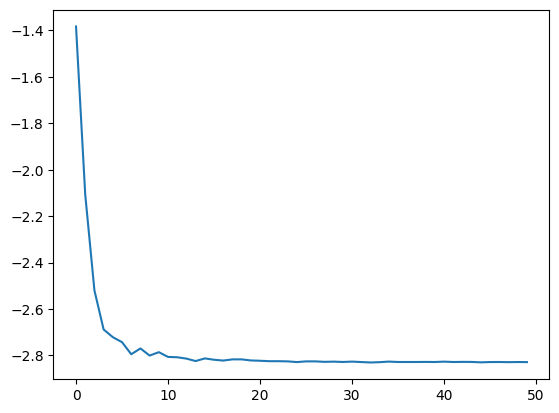

In [ ]:
import matplotlib.pyplot as plt

plt.plot(energy_history)

#### **NetKet Optimizer**

In [ ]:
# NetKet has several optimizer types, but we select SGD with learning rate 0.05
optimizer = nk.optimizer.Sgd(learning_rate=0.05)

# This is our optimization driver
gs = nk.driver.VMC(
    H,
    optimizer,
    variational_state=vstate,
    preconditioner=None
)

# Saves the data in the log. Several quantities can be accessed from here such as the mean, variance, stdev, etc.
log = nk.logging.RuntimeLog()

# Performs the optimization for 50 iterations
gs.run(n_iter=50, out=log)

energy = vstate.expect(H)
error = abs((energy.mean - E0) / E0)
print("Energy: ", energy)
print("Relative error: ", error)

  0%|          | 0/50 [00:00<?, ?it/s]

Energy:  -2.828421 ± 0.000011 [σ²=2.6e-07, R̂=1.006]
Relative error:  2.139081652888705e-06


Text(0, 0.5, 'Energy')

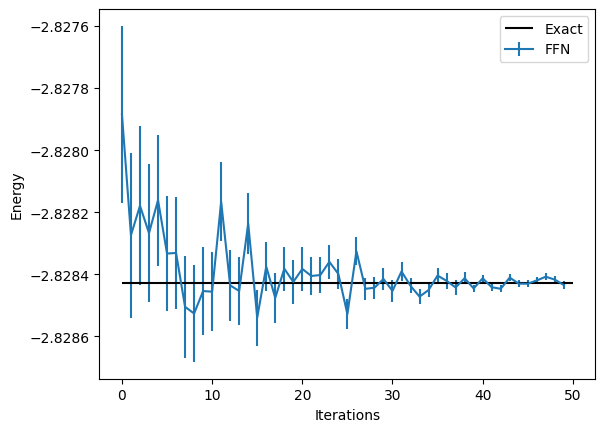

In [ ]:
import matplotlib.pyplot as plt

data_FFN = log.data
plt.errorbar(
    data_FFN["Energy"].iters,
    data_FFN["Energy"].Mean,
    yerr=data_FFN["Energy"].Sigma,
    label="FFN",
)
plt.hlines(E0, xmin=0, xmax=50, color="black", label="Exact")
plt.legend()

plt.xlabel("Iterations")
plt.ylabel("Energy")

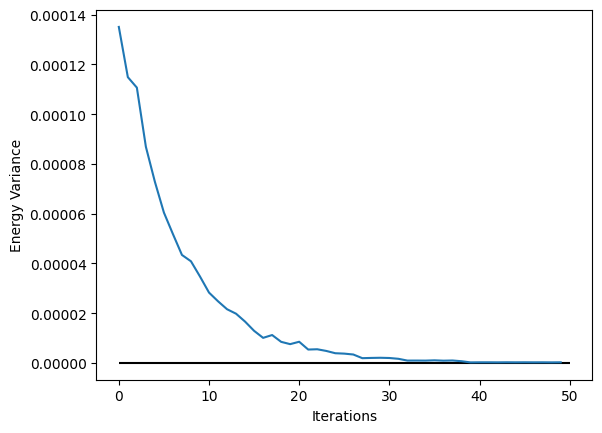

In [ ]:
plt.hlines(0, xmin=0, xmax=50, color="black")

plt.xlabel("Iterations")
plt.ylabel("Energy Variance")
plt.plot(data_FFN["Energy"].iters, data_FFN["Energy"].Variance)
# Observe how our variance approaches 0 as we approach the ground state

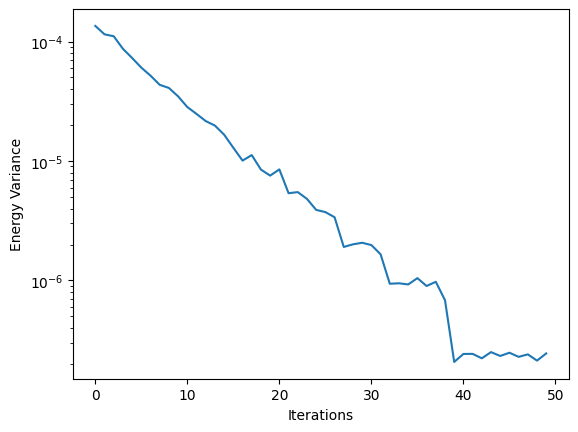

In [ ]:
# We can see just how precise our neural network representation is with a semi-log plot
plt.xlabel("Iterations")
plt.ylabel("Energy Variance")

plt.semilogy(data_FFN["Energy"].iters, data_FFN["Energy"].Variance)


## **Larger $N$ Problems**
The two-particle case is simply demonstrative. To show the capabilities of neural quantum states, we apply the same techniques to a 20-particle system. In this way, one gets a sense of how effectively the use of neural network quantum states breaks down the exponential problem.

### **Defining the Hamiltonian**

To make the problem a bit more challenging, let us consider an interacting Hamiltonian instead. Still under TFIM, consider

$$
H = -J\sum_{\langle i , j \rangle}\sigma^z_i\sigma^z_j - h_x\sum_{i}\sigma^x_i - h_z\sum_{i}\sigma^z_i
$$

where we have introduced a longitudinal field in addition to our transverse field. The interaction between our system's spins and these two fields makes the problem more complex and not solvable analytically.  

In [ ]:
N = 20

hilbert = nk.hilbert.Spin(s=1 / 2, N=N)

print("Randomly Generated States from the Hilbert Space:")
hilbert.random_state(jax.random.key(0), 4)

Randomly Generated States from the Hilbert Space:


Array([[-1, -1, -1, -1, -1, -1,  1,  1,  1,  1,  1, -1,  1,  1, -1,  1,
         1, -1, -1,  1],
       [ 1,  1,  1, -1, -1,  1,  1,  1, -1, -1,  1,  1,  1, -1, -1,  1,
        -1,  1,  1,  1],
       [ 1, -1,  1, -1, -1,  1,  1,  1,  1, -1,  1,  1, -1,  1, -1, -1,
         1,  1, -1, -1],
       [ 1,  1, -1,  1,  1,  1,  1, -1,  1, -1,  1, -1, -1, -1,  1,  1,
        -1,  1,  1,  1]], dtype=int8)

In [ ]:
from math import sqrt
sigmax = nk.operator.spin.sigmax
sigmaz = nk.operator.spin.sigmaz

J = 2.0
h_x = 1.0
h_z = 0.2

# Instead of summing over operators, we can also define them within NetKet's framework

# This defines our longitudinal field
H_l = nk.operator.LocalOperator(hilbert)
for i in range(N):
    H_l += -h_z * sigmaz(hilbert, i)

print(H_l)

# This defines the general shape of our system, where for TFIM we consider them a chain
lattice = nk.graph.Chain(N, pbc = False)

# the Ising operator in NetKet uses J - h_x so we adjust for sign convention
H = nk.operator.Ising(hilbert, lattice, h=h_x, J=-J) + H_l
print(H)

# Here is the equivalent summed version
# H = -J*sum([sigmaz(hilbert, i) @ sigmaz(hilbert, (i + 1)) for i in range(N-1)]) - h_x*sum([sigmax(hilbert, i) for i in range(N)])  - h_z*sum([sigmaz(hilbert, i) for i in range(N)])


LocalOperatorJax(dim=20, #acting_on=20 locations, constant=0.0, dtype=float64)
LocalOperatorJax(dim=20, #acting_on=39 locations, constant=0.0, dtype=float64)


### **Exact Diagonalization**

One can see the problems with attempting to calculate the eigenvalues for a matrix of size $2^N \times 2^N$. Even for relatively small $N$, normal-sized laptops are unable to store the data needed to handle such calculations. So, we convert the Hamiltonian into a *sparse* matrix by only storing the coordinates of nonzero elements, as one can see below.

In [ ]:
# Our computational power cannot handle a dense matrix, so we make use of a sparse
H_sparse = H.to_sparse()

Next, we make use of **exact diagonalization**

In [ ]:
from scipy.sparse.linalg import eigsh

eig_vals, eig_vecs = eigsh(H_sparse, k=2, which="SA")

print("eigenvalues with scipy sparse:", eig_vals)

E0 = eig_vals[0]

eigenvalues with scipy sparse: [-44.6276824  -41.11458631]


### **Neural-Network Quantum State (NQS)**

In [ ]:
import jax.numpy as jnp
from flax import nnx

# We make some changes so that our model becomes holomorphic - able to represent complex states
# In general, for real valued observables such as energy, non-holomorphic models will be more well behaved, especially in terms of optimization
# In comparison, holomorphic models inherently make use of complex-valued weights, so they can be a bit more difficult

class FFNN(nnx.Module):

    def __init__(self, N: int, alpha: int = 1, *, rngs: nnx.Rngs):
        self.alpha = alpha
        self.linear = nnx.Linear(
            in_features=N,
            out_features= alpha * N,
            param_dtype=complex, # Now, our parameters and outputs can be complex
            dtype = complex,
            rngs=rngs
        )

    def __call__(self, x: jax.Array):
        x = x.astype(complex)

        # We maintain the same single linear layer
        x = self.linear(x)

        # ReLu is non-holomorphic, unless redefined. NetKet features a version of ReLu that simply applies it separately to the real and imag parts of the input
        # Other activations like ln(cosh(x)) are also non-holomorphic, but their Taylor Expansion to some degree n is holomorphic
        x = nk.nn.activation.log_cosh(x)
        return jnp.sum(x, axis=-1)


sampler = nk.sampler.MetropolisLocal(hilbert)
model = FFNN(N=N, alpha=3, rngs=nnx.Rngs(2))

vstate = nk.vqs.MCState(sampler, model, n_samples=10000)
W_0 = vstate.parameters # Save the parameters so we can try different optimization methods

### **Variational Monte Carlo**
For more simple optimization schemes like SGD, it is common for the model to "get stuck" at other eigenvalues or local minima because the energy appears to be minimized. To mitigate this, we introduce more complex optimization schemes, with regards to how the geometry of our parameter space (the space containing all possible parameters) behaves.



In [ ]:
optimizer = nk.optimizer.Sgd(learning_rate=0.01)

gs = nk.driver.VMC(
    H,
    optimizer,
    variational_state=vstate,
    preconditioner=None
)

log_noSR = nk.logging.RuntimeLog()

# Performs the optimization for 50 iterations
gs.run(n_iter=200, out=log_noSR)

energy = vstate.expect(H)
error = abs((energy.mean - E0) / E0)
print("Energy: ", energy)
print("Relative error: ", error)

  0%|          | 0/200 [00:00<?, ?it/s]

Energy:  -17.4990-0.0037j ± 0.0082 [σ²=4.3e-01, R̂=1.001]
Relative error:  0.6078892326190675


#### **Stochastic Reconfiguration**

In our neural network, the geometry of our parameter space is actually more resemblant of a **curved manifold** rather than flat space. In other words, some parameters may affect our model more than others, so a simple gradient is not always the fastest direction to minimize energy (in curved geometry, a straight line is not necessarily the shortest distance between two points).

Instead, one can imagine finding the steepest portion of this manifold and allowing our optimization scheme to follow that instead. That steep portion is what we refer to as the **natural gradient** and it is what we follow in **stochastic reconfiguration**.



In [ ]:
vstate.parameters = W_0
optimizer = nk.optimizer.Sgd(learning_rate=0.01)

# This driver implicitly uses Stochastic Reconfiguration
gs = nk.driver.VMC_SR(
    H,
    optimizer,
    variational_state=vstate,
    diag_shift = 0.01
)

log_SR = nk.logging.RuntimeLog()
gs.run(n_iter=200, out=log_SR)

energy = vstate.expect(H)
error = abs((energy.mean - E0) / E0)
print("Energy: ", energy)
print("Relative error: ", error)

Automatic SR implementation choice:  QGT


  0%|          | 0/200 [00:00<?, ?it/s]

Energy:  -44.6149+0.0022j ± 0.0029 [σ²=8.3e-02, R̂=1.001]
Relative error:  0.00029095800235060725


/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/usr/local/lib/python3.12/dist-packages/numpy/ma/core.py:3413: ComplexWarning: Casting complex values to real discards the imaginary part
  _data[indx] = dval


Text(0, 0.5, 'Energy')

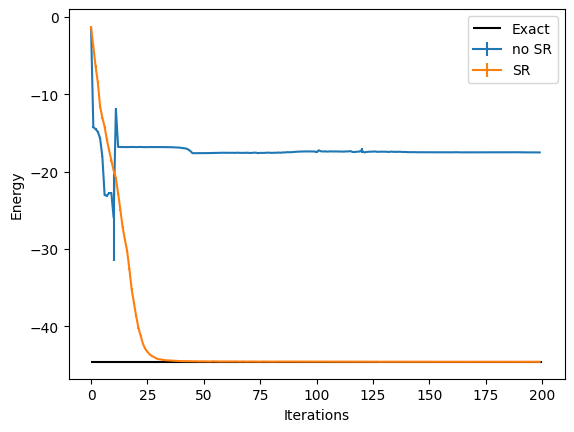

In [ ]:
data_noSR = log_noSR.data
data_SR = log_SR.data

import matplotlib.pyplot as plt

plt.errorbar(
    data_noSR["Energy"].iters,
    data_noSR["Energy"].Mean,
    yerr=data_noSR["Energy"].Sigma,
    label="no SR",
)

plt.errorbar(
    data_SR["Energy"].iters,
    data_SR["Energy"].Mean,
    yerr=data_SR["Energy"].Sigma,
    label="SR",
)
plt.hlines(E0, xmin=0, xmax=200, color="black", label="Exact")
plt.legend()

plt.xlabel("Iterations")
plt.ylabel("Energy")

# Compare how the SR improves the optimization significantly where just SGD gets stuck on a higher eigenvalue

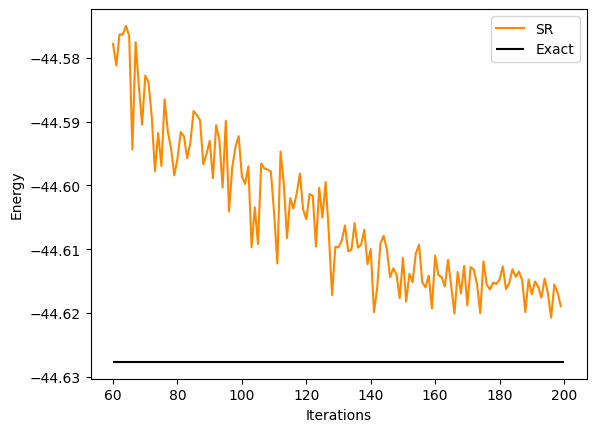

In [ ]:
# Examine how precise SR is when optimizing

plt.xlabel("Iterations")
plt.ylabel("Energy")

plt.plot(
    data_SR["Energy"].iters[60:200],
    data_SR["Energy"].Mean[60:200],
    color = '#FF8800',
    label = 'SR'
)

plt.hlines(E0, xmin=60, xmax=200, color="black", label="Exact")

plt.legend()

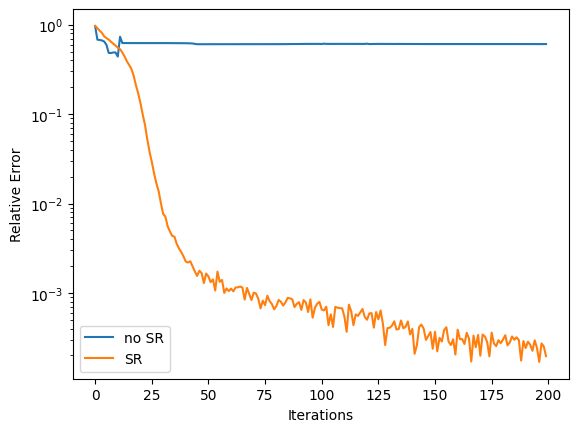

In [ ]:
# Examining the relative error as the model is optimized

rel_err_noSR = []
rel_err_SR = []

for i in log_noSR['Energy']['Mean']:
  rel_err_noSR.append(abs((i - E0) / E0))

for i in log_SR['Energy']['Mean']:
  rel_err_SR.append(abs((i - E0) / E0))

plt.xlabel("Iterations")
plt.ylabel("Relative Error")

plt.semilogy(data_SR["Energy"].iters, rel_err_noSR, label="no SR")
plt.semilogy(data_SR["Energy"].iters, rel_err_SR, label="SR")
plt.legend()

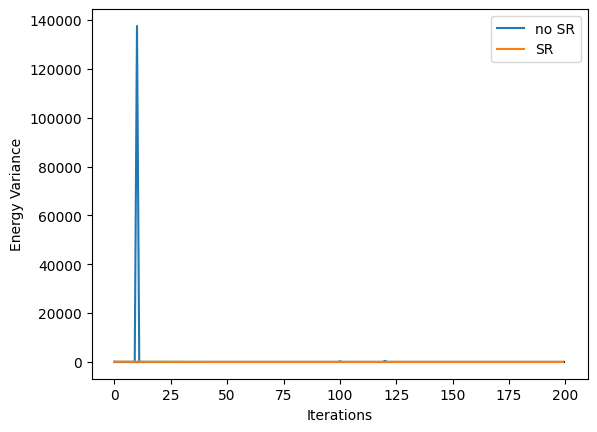

In [ ]:
plt.hlines(0, xmin=0, xmax=200, color="black")

plt.xlabel("Iterations")
plt.ylabel("Energy Variance")

plt.plot(data_noSR["Energy"].iters, data_noSR["Energy"].Variance, label="no SR")
plt.plot(data_SR["Energy"].iters, data_SR["Energy"].Variance, label="SR")
plt.legend()
# Observe how our variance approaches 0 as we approach the ground state

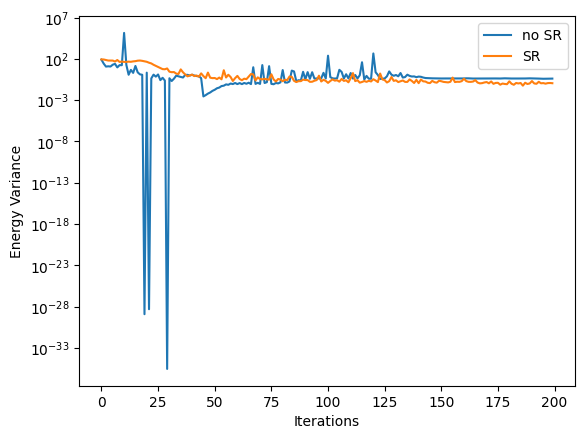

In [ ]:
plt.xlabel("Iterations")
plt.ylabel("Energy Variance")

# While the value of the variance does not seem to differ between the two. The non-SR optimizer is much more prone to fluctuations and getting stuck on non-ground state eigenstates

plt.semilogy(data_noSR["Energy"].iters, data_noSR["Energy"].Variance, label="no SR")
plt.semilogy(data_SR["Energy"].iters, data_SR["Energy"].Variance, label="SR")
plt.legend()

## **Time Evolution**

Now, let us consider the time-dependent form of the Schrödinger Equation,

$$i\hbar \frac{\partial}{\partial t}\psi(t) = H \psi(t).$$

This version of the Schrödinger Equation seeks not only to describe a quantum state, but to describe how it changes through time, referred to as its **time evolution**. For any closed quantum state, this evolution is

$$
|\psi(t+dt)\rangle=e^{-iHdt}|\psi(t)\rangle.
$$

### **Time-Dependent Variational Principle (TDVP)**

Now, we consider the quantum state built on our parameters $|\psi_{p(t)}\rangle$. To determine the time evolution of this state is to determine how best to approximate the exact state within the current parameter space. In other words, we are to optimize our parameters $p(t + dt)$, such that $|\psi_{p(t + dt)}\rangle$ is **as close as possible** to the exact evolution $e^{-iHdt}|\psi_{p(t)}\rangle$.


### **TDVP Derivation for Short Time Evolution (Schmitt & Heyl, 2025)**



To quantify this distance between the states, we use the **Fubini-Study Metric** defined as below:

$$
  D_{FS}(|\psi\rangle, |\phi\rangle) = \arccos \sqrt{\frac{\langle\psi |\phi \rangle \langle\phi |\psi \rangle}{\langle\phi |\phi \rangle \langle\psi | \psi\rangle}}
$$

Thus, our goal would be to find the minimum of this value for our states $e^{-iHdt}|\psi_{p(t)}\rangle$ and  $|\psi_{p(t)+\dot{p}dt}\rangle$. Considering that $dt$ is an infinitesimal time step, we can write the short-time expansions of our states as

$$
  |\psi_{p(t)+\dot{p}dt}\rangle = |\psi_{p}\rangle + dt \sum_x \dot{p_x} \, |\partial_x\psi_{p}\rangle +  𝒪(dt^2)
$$

$$
  e^{-iHdt}|\psi_{p(t)}\rangle = |\psi_{p}\rangle - iHdt |\psi_{p}\rangle +  𝒪(dt^2)
$$

where $\dot{p} = \frac{dp}{dt}$ is the time derivative of our parameters and $\partial_x = \frac{\partial}{\partial p_x}$. So, defining some minimized distance:

$$
\begin{align*}
|\delta\psi\rangle &= |\psi_{p+\dot{p}dt}\rangle - e^{-iHdt}|\psi_{p(t)}\rangle \\
&= dt \sum_x \dot{p_x} \, |\partial_x\psi_{p}\rangle + iHdt |\psi_{p}\rangle = dt \left[\sum_x \dot{p_x} \, |\partial_x\psi_{p}\rangle + iH |\psi_{p}\rangle \right]
\end{align*}
$$

We find the Fubini-Study Metric for our current state and the evolved one:

$$
\begin{align*}
  D_{FS}(|\psi\rangle, |\psi + \delta\psi\rangle)
  &= \arccos \sqrt{\frac{\langle\psi |\psi + \delta\psi\rangle \langle\psi + \delta\psi |\psi \rangle}{\langle\psi + \delta\psi|\psi + \delta\psi \rangle \langle\psi | \psi\rangle}}
\end{align*}
$$

Simplifying inside the square root, we have

$$
\begin{align*}
  \\ &= \frac{(\langle\psi|\psi\rangle + \langle\psi|\delta\psi\rangle)(\langle\psi|\psi\rangle + \langle\delta\psi|\psi\rangle)}
  {(\langle\psi | \psi\rangle + \langle\psi | \delta\psi\rangle +  \langle\delta\psi | \psi\rangle + \langle\delta\psi |\delta \psi\rangle )\langle\psi | \psi\rangle}
  \\ &= \frac{\langle\psi|\psi\rangle^2 + \langle\psi|\psi\rangle (\langle\psi|\delta\psi\rangle+\langle\delta\psi|\psi\rangle) + (\langle\psi|\delta\psi\rangle\langle\delta\psi|\psi\rangle)}
  {(\langle\psi | \psi\rangle^2 + \langle\psi | \psi\rangle(\langle\psi | \delta\psi\rangle +  \langle\delta\psi | \psi\rangle) + \langle\psi | \psi\rangle\langle\delta\psi |\delta \psi\rangle)}
  \\ &= \frac{1 + \frac{\langle\psi|\delta\psi\rangle+\langle\delta\psi|\psi\rangle}{\langle\psi|\psi\rangle} + \frac{\langle\psi|\delta\psi\rangle\langle\delta\psi|\psi\rangle}{\langle\psi|\psi\rangle^2}}
  {1 + \frac{\langle\psi | \delta\psi\rangle +  \langle\delta\psi | \psi\rangle}{\langle\psi|\psi\rangle} + \frac{\langle\delta\psi |\delta \psi\rangle}{\langle\psi|\psi\rangle}}
\end{align*}
$$

Using the approximation for small $x$, $\frac{1}{1+x} = 1-x+x^2$ because $| \delta\psi\rangle << | \psi\rangle $ (recall the $dt$ in | \delta\psi\rangle)

$$
\begin{align*}
  \\ &= \left(1
  + \frac{\langle\psi|\delta\psi\rangle+\langle\delta\psi|\psi\rangle}{\langle\psi|\psi\rangle}
  + \frac{\langle\psi|\delta\psi\rangle\langle\delta\psi|\psi\rangle}{\langle\psi|\psi\rangle^2}\right)
  \left(1
  - \frac{\langle\psi | \delta\psi\rangle +  \langle\delta\psi | \psi\rangle}{\langle\psi|\psi\rangle}
  - \frac{\langle\delta\psi |\delta \psi\rangle}{\langle\psi|\psi\rangle}\right)
  \\ &= 1 -\frac{\langle\psi | \delta\psi\rangle +  \langle\delta\psi | \psi\rangle}{\langle\psi|\psi\rangle}  -  \frac{\langle\delta\psi |\delta \psi\rangle}{\langle\psi|\psi\rangle} + \frac{\langle\psi|\delta\psi\rangle+\langle\delta\psi|\psi\rangle}{\langle\psi|\psi\rangle}  - \left(\frac{\langle\psi|\delta\psi\rangle+\langle\delta\psi|\psi\rangle}{\langle\psi|\psi\rangle}\frac{\langle\psi | \delta\psi\rangle +  \langle\delta\psi | \psi\rangle}{\langle\psi|\psi\rangle}   \right) - \left(\frac{\langle\psi|\delta\psi\rangle+\langle\delta\psi|\psi\rangle}{\langle\psi|\psi\rangle}\frac{\langle\delta\psi |\delta \psi\rangle}{\langle\psi|\psi\rangle}  \right) + \frac{\langle\psi|\delta\psi\rangle\langle\delta\psi|\psi\rangle}{\langle\psi|\psi\rangle^2} - \left(\frac{\langle\psi|\delta\psi\rangle\langle\delta\psi|\psi\rangle}{\langle\psi|\psi\rangle^2}\frac{\langle\psi | \delta\psi\rangle +  \langle\delta\psi | \psi\rangle}{\langle\psi|\psi\rangle}  \right) - \left(\frac{\langle\psi|\delta\psi\rangle\langle\delta\psi|\psi\rangle}{\langle\psi|\psi\rangle^2}\frac{\langle\delta\psi |\delta \psi\rangle}{\langle\psi|\psi\rangle} \right)
\end{align*}
$$

With this same assumption, $\langle\psi | \delta\psi\rangle << \langle\psi | \psi\rangle $, we can disregard all multiplied terms compared to $1$:

$$
\begin{align*}
  &= 1 -  \frac{\langle\delta\psi |\delta \psi\rangle}{\langle\psi|\psi\rangle}
+ \frac{\langle\psi|\delta\psi\rangle\langle\delta\psi|\psi\rangle}{\langle\psi|\psi\rangle^2}
\\  &= 1 -  \left( \frac{\langle\delta\psi |\delta \psi\rangle}{\langle\psi|\psi\rangle}
- \frac{\langle\psi|\delta\psi\rangle\langle\delta\psi|\psi\rangle}{\langle\psi|\psi\rangle^2}\right)
\end{align*}
$$

The Taylor expansion of $\sqrt{1-x} = 1 - \frac{1}{2}x + 𝒪(x^2)$, so:

$$
\begin{align*}
 \sqrt{1 -  \left( \frac{\langle\delta\psi |\delta \psi\rangle}{\langle\psi|\psi\rangle}
- \frac{\langle\psi|\delta\psi\rangle\langle\delta\psi|\psi\rangle}{\langle\psi|\psi\rangle^2}\right)}  &= 1 - \frac{1}{2} \left( \frac{\langle\delta\psi |\delta \psi\rangle}{\langle\psi|\psi\rangle}
- \frac{\langle\psi|\delta\psi\rangle\langle\delta\psi|\psi\rangle}{\langle\psi|\psi\rangle^2}\right) + 𝒪(dt^4)
\end{align*}
$$

And, the Taylor expansion of $arccos(1-x) = \sqrt{2x} + 𝒪(x^{3/2})$:
$$
\begin{align*}
\arccos \left(1 - \frac{1}{2} \left( \frac{\langle\delta\psi |\delta \psi\rangle}{\langle\psi|\psi\rangle}
- \frac{\langle\psi|\delta\psi\rangle\langle\delta\psi|\psi\rangle}{\langle\psi|\psi\rangle^2}\right)\right) = \sqrt{\frac{\langle\delta\psi |\delta \psi\rangle}{\langle\psi|\psi\rangle}
- \frac{\langle\psi|\delta\psi\rangle\langle\delta\psi|\psi\rangle}{\langle\psi|\psi\rangle^2}} + 𝒪(dt^3)
\end{align*}
$$

In the short time expansion, note that minimizing $D_{FS}$ should yield the same minimizer as its square $D_{FS}$, so we drop the square root and can rewrite this as:
$$
 D_{FS}^2(|\psi\rangle, |\psi + \delta\psi\rangle)  = \langle\delta\psi| \left(\frac{I}{\langle\psi|\psi\rangle}
- \frac{|\psi\rangle\langle\psi|}{\langle\psi|\psi\rangle^2}\right) |\delta \psi\rangle + 𝒪(dt^3)
$$

Substituting gives us
$$
\begin{align*}
 D_{FS}^2(|\psi\rangle, |\psi + \delta\psi\rangle)  
 &= \left( dt \left[\sum_x \dot{p_x} \, \langle\partial_x\psi_{p}| - i \langle\psi_{p}| H  \right] \right)\left(\frac{I}{\langle\psi|\psi\rangle}
- \frac{|\psi\rangle\langle\psi|}{\langle\psi|\psi\rangle^2}\right) \left( dt \left[\sum_x \dot{p_x}  \, |\partial_x\psi_{p}\rangle + iH |\psi_{p}\rangle  \right] \right) + 𝒪(dt^3)
 \\ &= (dt)^2\left( \sum_x \dot{p_x} \, \langle\partial_x\psi_{p}| - i \langle\psi_{p}| H  \right)\left(\frac{I}{\langle\psi|\psi\rangle}
- \frac{|\psi\rangle\langle\psi|}{\langle\psi|\psi\rangle^2}\right) \left( \sum_x \dot{p_x}  \, |\partial_x\psi_{p}\rangle + iH|\psi_{p}\rangle \right) + 𝒪(dt^3)
\end{align*}
$$

With the metric tensor of the Fubini-Study metric being $G = \frac{I}{\langle\psi|\psi\rangle}
- \frac{|\psi\rangle\langle\psi|}{\langle\psi|\psi\rangle^2}$, we now have:
$$
\begin{align*}
 &= (dt)^2\left( \sum_x \dot{p_x} \, \langle\partial_x\psi_{p}| - i \langle\psi_{p}| H   \right)G\left( \sum_x \dot{p_x}  \, |\partial_x\psi_{p}\rangle + iH |\psi_{p}\rangle \right) + 𝒪(dt^3)
 \\
 &= (dt)^2\left(\sum_{x,x'}\dot{p_x} \dot{p_{x'}} \langle \partial_x\psi_p | G | \partial_{x'}\psi_p\rangle + \sum_x\dot{p_x}\langle \partial_x\psi_p | G (iH| \psi_p\rangle) + \sum_x\dot{p_x}({-}i\langle \psi_p | H )G |\partial_x\psi_p\rangle
  + ({-}i\langle \psi_p | H )G (iH| \psi_p\rangle) \right) + 𝒪(dt^3)
  \\
 &= (dt)^2\left(\sum_{x,x'}\dot{p_x} \dot{p_{x'}} \langle \partial_x\psi_p | G | \partial_{x'}\psi_p\rangle
 - \left(
  -i\sum_x\dot{p_x}\left(\langle \partial_x\psi_p | G (H| \psi_p\rangle)
  +  (\langle \psi_p | {-}H )G |\partial_x\psi_p\rangle  \right)
 \right)
 + (\langle \psi_p | H )G (H| \psi_p\rangle) \right) + 𝒪(dt^3)
\end{align*}
$$

With our first term, we can write it in this form, defining our **Quantum Geometric Tensor (QGT)** $S_{x,x'}^p$:

$$
\begin{align*}
\sum_{x,x'} S_{x,x'}^p\dot{p_x} \dot{p_{x'}}
\end{align*}
\begin{align*}
S_{x,x'}^p =  \langle \partial_x\psi_p | G | \partial_{x'}\psi_p\rangle &= \langle \partial_x\psi_p | \left(\frac{I}{\langle\psi_p|\psi_p\rangle}
- \frac{|\psi_p\rangle\langle\psi_p|}{\langle\psi_p|\psi_p\rangle^2} \right) | \partial_{x'}\psi_p\rangle
\\ &= \frac{\langle\partial_x \psi_p | \partial_{x'} \psi_p\rangle}{\langle \psi | \psi \rangle} - \frac{\langle\partial_x \psi_p | \psi_p\rangle\langle \psi_p | \partial_{x'} \psi_p\rangle}{\langle \psi | \psi \rangle^2}
\end{align*}
$$

For the second term, notice that:
$$
((\langle \psi_p |{-}H )G |\partial_x\psi_p\rangle) = \langle \partial_x\psi_p | G (H| \psi_p\rangle)^*
$$
and
$$
\langle \phi | \psi \rangle + \langle \phi | \psi \rangle^* = 2\text{Re}(\langle \phi | \psi \rangle).
$$
So, we must have

$$
\begin{align*}
 -i\sum_x\dot{p_x}\left((\langle \psi_p | {-}H )G |\partial_x\psi_p\rangle  
  + \langle \partial_x\psi_p | G (H| \psi_p\rangle) \right)
  &= -i\sum_x\dot{p_x}\left(\langle \partial_x\psi_p | G (H| \psi_p\rangle)^*
  + (\langle \psi_p | H )G |\partial_x\psi_p\rangle \right)
  \\ &=
  -i\sum_x 2\text{Re}[\langle \partial_x\psi_p | G (H| \psi_p\rangle)]\dot{p_x}
  \\ &=
  \sum_x 2\text{Re}[F_x^p]  \dot{p_x}
\end{align*}
$$

where $F_x^p$ is our **force vector**, defined as:

$$
\begin{align*} 
  F_x^p = -i \left[ \langle \partial_x\psi_p | G (H| \psi_p\rangle) \right] &= -i \left[ \langle \partial_x\psi_p | \left(\frac{I}{\langle\psi_p|\psi_p\rangle}
- \frac{|\psi_p\rangle\langle\psi_p|}{\langle\psi_p|\psi_p\rangle^2} \right) (H| \psi_p\rangle)  \right]
  \\ &=
  - i \left[ \frac{\langle\partial_x \psi_p | H |  \psi_p\rangle}{\langle \psi | \psi \rangle} - \frac{\langle\partial_x \psi_p | \psi_p\rangle\langle \psi_p | H | \psi_p\rangle}{\langle \psi | \psi \rangle^2}  \right]
\end{align*}
$$

Now, with the last term, notice that this is simply the variance of $H$:

$$
\begin{align*}
\left(\frac{I}{\langle\psi_p|\psi_p\rangle}
- \frac{|\psi_p\rangle\langle\psi_p|}{\langle\psi_p|\psi_p\rangle^2} \right)(H| \psi_p\rangle) &= \frac{H| \psi_p\rangle}{\langle\psi_p|\psi_p\rangle}
- \frac{|\psi_p\rangle\langle\psi_p|H| \psi_p\rangle}{\langle\psi_p|\psi_p\rangle^2}
\end{align*}
$$

$$
\begin{align*}
(\langle \psi_p | H ) \left( \frac{H| \psi_p\rangle}{\langle\psi_p|\psi_p\rangle}
- \frac{|\psi_p\rangle\langle\psi_p|H| \psi_p\rangle}{\langle\psi_p|\psi_p\rangle^2} \right) &= \frac{\langle \psi_p | H^2| \psi_p\rangle}{\langle\psi_p|\psi_p\rangle}
- \frac{\langle\psi_p|H| \psi_p\rangle^2}{\langle\psi_p|\psi_p\rangle^2}
\\ &= \langle H^2 \rangle - \langle H \rangle^2 = \text{var}({H})
\end{align*}
$$

So, we have our equation:
$$
D_{FS}^2(|\psi\rangle, |\psi + \delta\psi\rangle)  = (dt^2) \left[ \sum_{x,x'} S_{x,x'}^p\dot{p_x} \dot{p_{x'}} - 2\sum_x \text{Re}[F_x^p]  \dot{p_x} + \text{var}(H) \right] +  𝒪(dt^3)
$$

Finding the minimum of this by taking the derivative with respect to $\dot{p_x}$ would then give us:

$$
\begin{align*}
  0 &= \sum_{x'}(S_{x,x'}^p + S_{x',x}^p)\dot{p_{x'}} - 2\text{Re}[F_x^p] \\
  \sum_{x'}\text{Re}[S_{x,x'}^p]\dot{p_{x'}} &= \text{Re}[F_x^p]
\end{align*}
$$

This is our TDVP equation, which we can use to find the time evolution of our state.

### **TDVP Equation**

Our derivation leads to our TDVP equation

$$
\sum_{x'} \text{Re}[S^p_{x,x'}]\,\dot{p_{x'}} =  \text{Re}[F^p_x]
$$

where $S^p_{x,x'}$ is our Quantum Geometric Tensor (QGT) and F is our *force vector*.

$$
S^p_{x,x'} = \frac{\langle\partial_x \psi_p | \partial_{x'} \psi_p\rangle}{\langle \psi | \psi \rangle} - \frac{\langle\partial_x \psi_p | \psi_p\rangle\langle \psi_p | \partial_{x'} \psi_p\rangle}{\langle \psi | \psi \rangle^2}
$$

$$
F^p_x = i \left[ \frac{\langle\partial_x \psi_p | H |  \psi_p\rangle}{\langle \psi | \psi \rangle} - \frac{\langle\partial_x \psi_p | \psi_p\rangle\langle \psi_p | H | \psi_p\rangle}{\langle \psi | \psi \rangle^2}  \right]
$$

Note that this is a first-order differential equation in $p$, so to solve this, we must pick an appropriate method of solving.

### **Quench**

In the code above we have previously found the ground state energy and have thus found the parameters that describe this 20-particle chain's ground state wavefunction. Now, to examine the time evolution of this system, we can change the transverse field $h_f \neq h_i$. This process is referred to as a **quench**.

In [ ]:
# We save the ground state parameters for the previous system
W_gs = vstate.parameters

In [ ]:
# We now change h
h_x = 0.5

H_f = nk.operator.Ising(hilbert, lattice, h=h_x, J=-J) + H_l
#H_f = -J*sum([sigmaz(hilbert, i) @ sigmaz(hilbert, (i + 1)) for i in range(N-1)]) - h_x*sum([sigmax(hilbert, i) for i in range(N)]) - h_z*sum([sigmaz(hilbert, i) for i in range(N)])

We also define the **observable** that we are interested in seeing the time evolution of. Here, we select the observable
$$
S_x = \frac{1}{N}\sum_i^N\sigma^x_i
$$

because we are quenching with a change in $h_x$. This observable is a measure of how aligned our spins are in the transverse direction. A value farther from 0 means the spins are more aligned in $x$ than in the $z$.

In [ ]:
Sx = sum([sigmax(hilbert, i) for i in range(N)])/N

### **Exact Solution**

Using another Python library, **QuTiP** (Quantum Toolkit in Python), we can compare our NQS, t-VMC solution with the exact time evolution of our spin system.

In [ ]:
%pip install --quiet qutip
import qutip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.1/33.1 MB 69.0 MB/s eta 0:00:00


In [ ]:
time = np.linspace(0.0, 1.0, 200) # t_start, t_end, n_intervals
vstate.parameters = W_gs # recall the ground state parameters we had saved earlier

# sesolve is qutip's Schrodinger Equation solver for dynamics
# we use .to_qobj() to convert between NetKet and QuTiP objects
exact_soln = qutip.sesolve(H_f.to_qobj(),
                           vstate.to_qobj(),
                           time,
                           e_ops = Sx.to_qobj(),
                           options={"progress_bar": "tqdm"})

  0%|          | 0/199 [00:00<?, ?it/s]

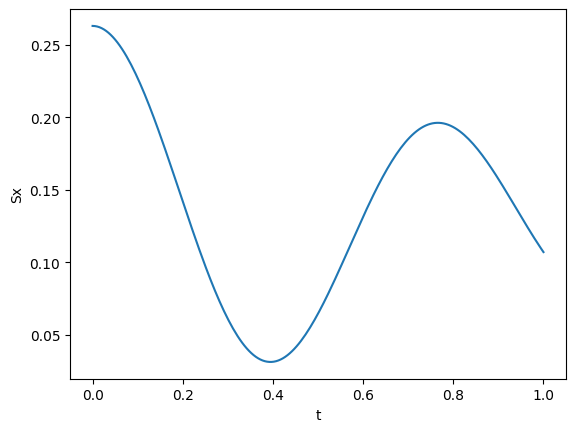

In [ ]:
import matplotlib.pyplot as plt
plt.xlabel("t")
plt.ylabel("Sx")


plt.plot(exact_soln.times, exact_soln.expect[0], label = "Exact")

### **Time-Dependent Variational Monte Carlo (*t-VMC*)**

Given our QGT,

$$
S^p_{x,x'} = \frac{\langle\partial_x \psi_p | \partial_{x'} \psi_p\rangle}{\langle \psi | \psi \rangle} - \frac{\langle\partial_x \psi_p | \psi_p\rangle\langle \psi_p | \partial_{x'} \psi_p\rangle}{\langle \psi | \psi \rangle^2},
$$

as with our local energy, we can write this in terms of statistical expectation values to facilitate Monte Carlo sampling. With our first term,

\begin{align*}
\frac{\langle\partial_x \psi_p | \partial_{x'} \psi_p\rangle}{\langle \psi | \psi \rangle}
&= \frac{\sum_{x}\langle\partial_{x} \psi_p|x\rangle \langle x|\partial_{x'} \psi_p\rangle}{\sum_x \langle\psi|x\rangle \langle x|\psi\rangle}
\\ &=
\frac{\sum_{x}(\partial_{x}\psi_p(x))^* (\partial_{x}\psi_p(x))}{\sum_x|\psi(x)|^2}
\\ &=
\frac{\sum_{x}(\partial_{x}\psi_p(x))^* (\partial_{x}\psi_p(x))(\frac{\langle\psi|x\rangle \langle x|\psi\rangle}{\langle\psi|x\rangle \langle x|\psi\rangle})}{\sum_x|\psi(x)|^2}
\\ &=
\frac{\sum_{x}|\psi(x)|^2\left(
  \frac{\partial_{x}\psi_p(x)}{\psi(x)}\right)^* \left( \frac{\partial_{x}\psi_p(x)}{\psi(x)} \right)}
  {\sum_x|\psi(x)|^2}
\end{align*}

So, we can define a local observable $O_{loc} = \frac{\partial_{x}\psi_p(x)}{\psi(x)}$, such that our expression becomes:

$$
\frac{\langle\partial_x \psi_p | \partial_{x'} \psi_p\rangle}{\langle \psi | \psi \rangle}  = \frac{\sum_{x}|\psi(x)|^2\,O_{loc}^*O_{loc}}
  {\sum_x|\psi(x)|^2} = \langle\langle O_{loc}^*O_{loc}\rangle\rangle
$$

Similarly, one can rewrite the second term in the form of a statistical expectation value, as well as the terms in our *force vector* $F_x^p$ allowing us to sample these values in the same way we did the local energy. In this way, the TDVP becomes the **Time-dependent Variational Monte Carlo** or **t-VMC**

In [ ]:
# NetKet allows us to set the parameters of our Time Evolution
# qgt and ode_solver simply define the quantum geometric tensor and ODE solver for us to use. We select simple choices for now
# dt is the size of steps for our time evolution. Typical values are smaller than 0.01

vstate.parameters = W_gs
time_evolution = nk.experimental.TDVP(
    H_f,
    vstate,
    ode_solver=nk.experimental.dynamics.Euler(dt=0.005),
    qgt=nk.optimizer.qgt.QGTAuto(holomorphic=True)
)

log = nk.logging.RuntimeLog()
time_evolution.run(1.0, out=log, show_progress=True, obs={"Sx": Sx})

  0%|          | 0.00/1.00 [00:00<?, ?it/s]

(RuntimeLog():
  keys = ['Sx', 'acceptance', 't', 'Generator'],)

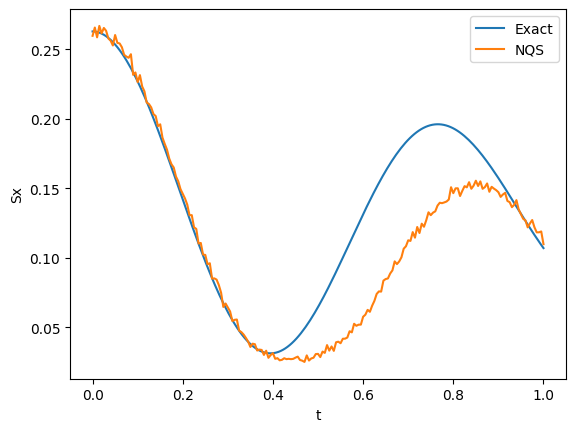

In [ ]:
plt.xlabel("t")
plt.ylabel("Sx")

plt.plot(exact_soln.times, exact_soln.expect[0], label = "Exact")
plt.plot(log.data["t"], log.data["Sx"].Mean.real, label = "NQS")
plt.legend()

While qualitatively, our t-VMC follows a similar path, it diverges from the exact solution after a fairly short time. These errors can accumulate from several sources including **sampling error**, **inexact solutions to the ODE**, **lack of expressivity for our variational states**, or **errors in projection/the TDVP itself** (difficulty projecting exact states onto our parameter space).

With this, let us reconsider the problem, approaching it with more complex feedforward architecture.

## **Multi-layered FFNN Architecture**

Now, we consider a model defined with two additional layers, beyond the current single linear layer.

In [ ]:
class MultiLayerFFNN(nnx.Module):

    def __init__(self, N: int, alpha: int = 1, *, rngs: nnx.Rngs):
        self.alpha = alpha

        self.linear_1 = nnx.Linear(
            in_features= N,
            out_features = alpha * N,
            param_dtype=complex,
            dtype = complex,
            rngs=rngs
        )
        self.linear_2 = nnx.Linear(
            in_features= alpha * N,
            out_features= N,
            param_dtype=complex,
            dtype = complex,
            rngs=rngs
        )
        self.linear_3 = nnx.Linear(
            in_features= N,
            out_features= N,
            param_dtype=complex,
            dtype = complex,
            rngs=rngs
        )
    def __call__(self, x: jax.Array):
        x = x.astype(complex)

        x = self.linear_1(x)
        x = self.linear_2(x)
        x = self.linear_3(x)
        x = nk.nn.activation.log_cosh(x)
        return jnp.sum(x, axis=-1)

And then, we prepare the ground state as we have before. Since we have already defined the Hamiltonian previously, let us go straight into the driving code.

In [ ]:
sampler = nk.sampler.MetropolisLocal(hilbert)
#model = MultiLayerFFNN(N=N, alpha=3, rngs=nnx.Rngs(2))
model = nk.models.RBM(alpha=2, param_dtype=complex, activation = nk.nn.activation.log_cosh)
model = ptvmc.nn.DiagonalWrapper(model, param_dtype=complex)


vstate = nk.vqs.MCState(sampler, model, n_samples=6000)
optimizer = nk.optimizer.Sgd(learning_rate=0.01)

gs = nk.driver.VMC_SR(
    H,
    optimizer,
    variational_state=vstate,
    diag_shift = 0.01,
    use_ntk = False
)

log_ML = nk.logging.RuntimeLog()
gs.run(n_iter=200, out=log_ML)

energy = vstate.expect(H)
error = abs((energy.mean - E0) / E0)
print("Energy: ", energy)
print("Relative error: ", error)

W_gs = vstate.parameters

  0%|          | 0/200 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
data_ML = log_ML.data

plt.errorbar(
    data_ML["Energy"].iters,
    data_ML["Energy"].Mean,
    yerr=data_ML["Energy"].Sigma,
    label="Multi-Layered FFNN",
)

plt.hlines(E0, xmin=0, xmax=200, color="black", label="Exact")
plt.legend()

plt.xlabel("Iterations")
plt.ylabel("Energy")

In [ ]:
vstate.parameters = W_gs
time_evolution = nk.experimental.TDVP(
    H_f,
    vstate,
    ode_solver=nk.experimental.dynamics.Euler(dt=0.005),
    qgt=nk.optimizer.qgt.QGTAuto(holomorphic=True),
)

log_ML = nk.logging.RuntimeLog()
time_evolution.run(1.0, out=log_ML, show_progress=True, obs={"Sx": Sx})

In [ ]:
plt.xlabel("t")
plt.ylabel("Sx")

plt.plot(exact_soln.times, exact_soln.expect[0], label = "Exact")
plt.plot(log.data["t"], log.data["Sx"].Mean.real, label = "1-Layer FFNN")
plt.plot(log_ML.data["t"], log_ML.data["Sx"].Mean.real, label = "3-Layer FFNN")
plt.legend()

## **Time Evolution: p-tVMC**

Now, we have seen that the typical t-VMC is prone to some errors. In particular, it can be shown that it inherently possesses a bias, which leads to inaccurate results for certain systems. Put in generalized terms, this bias occurs in scenarios where
$$
\psi_p = 0 \text{ and } \partial_x \psi_p \neq 0,
$$
which leads

### **Projected Quantum Dynamics**

Above, we derived the method of t-VMC to find the parameters $p$, solving the problem as an optimization:

$$
  \text{min}_{\dot{p}} \, D_{FS}(
    |\psi_{p(t)+\dot{p}dt}\rangle,
    e^{-iHdt}|\psi_{p(t)}\rangle
    )
$$

where we solve for $\dot{p}$ using the TDVP equation.

In comparison to this, the approach of projected quantum dynamics alters our optimization problem:

$$
  \text{min}_p \, 𝓛\left(
    |\psi_{p(t)}\rangle,
    e^{-iHdt}|\psi_{p(t)}\rangle
    \right)
$$

where $𝓛$ is some loss function that characterizes the distance between our functions. The difference is that instead of solving for $\dot{p}$, we find a way to solve directly for the parameters of our evolved state $p$.

With that, we are trying to solve the following equation:

$$
  |\psi_{p(t+dt)}\rangle=e^{-iHdt}|\psi_{p(t)}\rangle.
$$

However, we can generalize the problem in the form of some operators $V$ and $U$, such that:

$$
V|\psi_{p(t+dt)}\rangle=U|\psi_{p(t)}\rangle.
$$

where our goal is still minimization:

$$
p(t+dt) = \text{min}_p \, 𝓛(V|\psi_{p(t+dt)}\rangle,U|\psi_{p(t)}\rangle)
$$

$$
\text{min}_p \, 𝓛(|\psi_{p(t+dt)}\rangle,V^{-1}U|\psi_{p(t)}\rangle.)
$$

This second equation, then leads us to approximate our time propagator $e^{-iHdt}$ as a series of products:

$$
e^{-iHdt} = \prod_{x=1}^sV_x^{-1}U_x + 𝒪(dt^{o(s)+1})
$$

Think of this as decomposing our larger matrices into products of smaller ones. With this, the problem now essentially becomes a simple optimization for each of the $s$ elements. We have $p(t) = p_1$ and $p(t+dt) = p_s$

So now, the challenge becomes finding a valid $U$ and $V$ that we can work with. Several schemes for this exist, but in this notebook, we simply highlight Suzuki-Trotter decomposition as well as Diagonally-exact split schemes.


### **Suzuki-Trotter Decomposition**

### **Linear Product Expansion**

### **Fidelity**

Previously, we derived the equation for TDVP quantifying the "distance" between two states with the **Fubini-Study metric**. In this method, we introduce the new quantity of **fidelity** defined as

\begin{align*}
𝓕(|\psi\rangle, |\phi\rangle) &= \frac{\langle\psi |\phi\rangle}{\langle\psi |\psi\rangle}\frac{\langle\phi | \psi\rangle}{\langle\phi|\phi\rangle} \\
𝓕(V|\psi\rangle, U|\phi\rangle) &= \frac{\langle\psi |V^{\dagger}U| \phi\rangle}{\langle\psi |V^{\dagger}V|\psi\rangle}\frac{\langle\phi |U^{\dagger}V| \psi\rangle}{\langle\phi |U^{\dagger}U|\phi\rangle}
\end{align*}

It follows that the corresponding quantity known as infidelity is simply $𝓘 = 1-𝓕$

### **Projected Time-Dependent Variational Monte Carlo**

In [ ]:
model = nk.models.LogStateVector(hilbert = hilbert, param_dtype=complex)
model = ptvmc.nn.DiagonalWrapper(model, param_dtype=complex)
vstate = nk.vqs.MCState(sampler, model, n_samples=6000)

compression_alg = ptvmc.compression.InfidelityCompression(
    driver_class=advd.driver.InfidelityOptimizerNG,
    build_parameters={
        "diag_shift": 1e-6,
        "optimizer": optax.inject_hyperparams(optax.sgd)(learning_rate=0.05),
        "linear_solver_fn": nk.optimizer.solver.cholesky,
        "proj_reg": None,
        "momentum": None,
        "chunk_size_bwd": None,
        "collect_quadratic_model": True,
        "use_ntk": False,
        "cv_coeff": -0.5,
        "resample_fraction": None,
        "estimator": "cmc",
    },
    run_parameters={
        "n_iter": 100,
        "callback": [
            PI_controller_diagshift(
                target=0.9,
                safety_fac=1.0,
                clip_min=0.5,
                clip_max=2,
                diag_shift_min=1e-9,
                diag_shift_max=0.1,
                order=1,
                beta_1=0.9,
                beta_2=0.1,
            )
        ],
    },
)

NameError: name 'nk' is not defined

In [ ]:
solver = ptvmc.solver.SPPE3()

In [ ]:
integration_params = ptvmc.IntegrationParameters(dt=0.005)

generator = -1j * H_f

te_driver = ptvmc.PTVMCDriver(
    generator,
    0.0,
    solver=solver,
    integration_params=integration_params,
    compression_algorithm=compression_alg,
    variational_state=vstate,
)
te_driver.run(1.0)

ValueError: Unknown operation to act diagonally: ['Z' 'Z' 'Z' 'Z' 'Z' 'Z' 'Z' 'Z' 'Z' 'Z' 'Z' 'Z' 'Z' 'Z' 'Z' 'Z' 'Z' 'Z'
 'Z' 'Z' 'ZZ' 'ZZ' 'ZZ' 'ZZ' 'ZZ' 'ZZ' 'ZZ' 'ZZ' 'ZZ' 'ZZ' 'ZZ' 'ZZ' 'ZZ'
 'ZZ' 'ZZ' 'ZZ' 'ZZ' 'ZZ' 'ZZ']

In [ ]:
%pip install --quiet git+https://github.com/NeuralQXLab/ptvmc-systematic-study
%pip install --quiet qutip

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.1/33.1 MB 12.4 MB/s eta 0:00:00


In [ ]:
import qutip as qt
import numpy as np
import ptvmc

from functools import partial

import advanced_drivers as advd
from advanced_drivers._src.callbacks.autodiagshift import PI_controller_diagshift

from matplotlib import pyplot as plt

import optax

import netket as nk
from netket.optimizer.solver import cholesky
from netket.operator.spin import sigmax, sigmaz

import ptvmc._src.exact.epe_integrator
import ptvmc._src.exact.epe_solvers
from ptvmc._src.callbacks.logapply import DynamicLogApply as LogApply


# 2D Lattice
L = 2
g = nk.graph.Hypercube(length=L, n_dim=2, pbc=True)

# Hilbert space of spins on the graph
hi = nk.hilbert.Spin(s=1 / 2, N=g.n_nodes, inverted_ordering=False)

# Ising spin hamiltonian
J = 1
hc = 3.044 * J
h = 2 * hc
ha = sum([-J * sigmaz(hi, i) * sigmaz(hi, j) for i, j in g.edges()])
ha += sum([-h * sigmax(hi, i) for i in g.nodes()])

# LogState Spin Machine
ma = nk.models.LogStateVector(hilbert=hi)
# nk.models.RBM(alpha=5, use_visible_bias=True, param_dtype=complex)
ma = ptvmc.nn.DiagonalWrapper(ma, param_dtype=complex)

# Monte Carlo Sampling
sa = nk.sampler.ExactSampler(
    hilbert=hi,
)
# nk.sampler.MetropolisLocal(hi, n_chains=16)

# Variational State
vs = nk.vqs.MCState(sa, ma, n_samples=1024)

mx = sum([sigmax(hi, i) for i in g.nodes()]) / g.n_nodes

# Exact simulation
dt = 0.025
T = 1.

times_qo = np.linspace(0, T, 100)
qo_sol = qt.sesolve(
    ha.to_qobj(),
    vs.to_qobj(),
    times_qo,
    e_ops=[
        mx.to_qobj(),
    ],
    options={
        "progress_bar": True,
    },
)
times_qo = np.asarray(qo_sol.times)
mx_vals_qo = qo_sol.expect[0]

# State-vector PE simulation
f_apply = partial(ptvmc._src.exact.epe_solvers.PPE4, ha.to_sparse())
_, expect_epe = ptvmc._src.exact.epe_integrator.integrator(
    vs.to_array(),
    [
        mx.to_sparse(),
    ],
    T,
    dt,
    f_apply,
)
mx_vals_epe = expect_epe[:, 0].real
times_epe = np.arange(0, T + dt, dt)

# This function is called recursively as a callback to update the plot and give real-time information about the simulation
def plot_fn(logger):
    times_var = logger["times"]["value"]
    mx_vals_var = logger["mx"]["Mean"].real

    fig, ax = plt.subplots(2, 1, figsize=(4, 3), gridspec_kw={"height_ratios": [1.5, 1]})
    ax[0].plot(h * times_qo, mx_vals_qo, ls="-", c="darkgrey", label="Exact",)
    ax[0].plot(h * times_epe, mx_vals_epe, "o",  ms=5.5, markerfacecolor="none", markeredgecolor="red", markeredgewidth=1.05, label=solver.__repr__()[:-2],)
    ax[0].plot(h * times_var, mx_vals_var, "o", ms=4, c="steelblue", label="Var. " + solver.__repr__()[:-2],)
    ax[0].set_xticklabels([])

    ax[0].set_ylabel(r"$M_x$")
    ax[0].legend(ncol=3, loc=(-0.014,1.02), )

    color = ["#5DC350", "#986746"]
    # Access infidelity data from History2D structure
    infidelity_data = logger.data['Infidelity']
    if hasattr(infidelity_data, 'values'):
        # History2D structure: access the Mean values array directly
        # Shape is (n_timesteps, n_optimizer_iters)
        final_infidelities = infidelity_data['Mean'].real[:, -1]
        # Plot single line for final infidelity at each timestep
        ax[1].plot(h * times_var, final_infidelities, "o-", c=color[0], ms=6, label="final", markeredgecolor="k", markeredgewidth=0.4,)
    else:
        # Legacy dict structure
        final_infidelities = infidelity_data['Mean']['value']['value'].real[:, :, -1]
        for i in range(final_infidelities.shape[1]):
            ax[1].plot(h * times_var, final_infidelities[:, i], "o-", c=color[i],  ms=6, label=f"stage {i}", markeredgecolor="k", markeredgewidth=0.4,)
    ax[1].set_yscale("log")
    ax[1].set_ylabel(r"$\mathcal{I}$")
    ax[1].set_xlabel(r"$ht$")

    ax[0].set_xlim(-0.04*h, h*T*1.05)
    ax[1].set_xlim(-0.04*h, h*T*1.05)
    ax[1].set_ylim(1e-12, 1e-6)

# Define compression algorithm
compression_alg = ptvmc.compression.InfidelityCompression(
    driver_class=advd.driver.InfidelityOptimizerNG,
    build_parameters={
        "diag_shift": 1e-7,
        "optimizer": optax.inject_hyperparams(optax.sgd)(learning_rate=0.1),
        "linear_solver_fn": cholesky,
        "proj_reg": None,
        "momentum": None,
        "chunk_size_bwd": None,
        "collect_quadratic_model": True,
        "use_ntk": False,
        "cv_coeff": -0.5,
        "resample_fraction": None,
        "estimator": "cmc",
    },
    run_parameters={
        "n_iter": 250,
        "callback": [
            PI_controller_diagshift(
                target=0.9,
                safety_fac=1.,
                clip_min=0.5,
                clip_max=2,
                diag_shift_min=1e-11,
                diag_shift_max=0.1,
                order=1,
                beta_1=0.9,
                beta_2=0.1,
            )
        ],
    },
)

# Discretization scheme used to approximate the time-evolution operator
solver = ptvmc.solver.PPE4()

# Define the PTVMC driver
integration_params = ptvmc.IntegrationParameters(
    dt=dt,
)
generator = -1j * ha
driver = ptvmc.PTVMCDriver(
    generator,
    0.0,
    solver=solver,
    integration_params=integration_params,
    compression_algorithm=compression_alg,
    variational_state=vs,
)

logger = nk.logging.RuntimeLog()

callback = [
    LogApply(logger, plot_fn),
]

(out,) = driver.run(
    T=T,
    out=logger,
    obs={"mx": mx},
    obs_in_fullsum=True,
    callback=callback
)

10.1%. Run time:   0.00s. Est. time left: 00:00:00:00
20.2%. Run time:   0.00s. Est. time left: 00:00:00:00
30.3%. Run time:   0.00s. Est. time left: 00:00:00:00
40.4%. Run time:   0.00s. Est. time left: 00:00:00:00
50.5%. Run time:   0.00s. Est. time left: 00:00:00:00
60.6%. Run time:   0.01s. Est. time left: 00:00:00:00
70.7%. Run time:   0.01s. Est. time left: 00:00:00:00
80.8%. Run time:   0.01s. Est. time left: 00:00:00:00
90.9%. Run time:   0.01s. Est. time left: 00:00:00:00
100.0%. Run time:   0.01s. Est. time left: 00:00:00:00


/usr/local/lib/python3.12/dist-packages/netket/graph/common_lattices.py:126: InitializePeriodicLatticeOnSmallLatticeWarning: 
You are attempting to define a lattice with length 2 in dimension 0 using periodic boundary condition.

Lattice with less than two sites in one direction does not support periodic boundary condition.
The behavior of the lattice is equivalent to an open boundary condition in this direction.

To avoid this warning, consider either using a lattice with more than two sites in the direction you want to be periodic,
or define the graph using :class:`~netket.graph.Graph` by adding the edges manually.


-------------------------------------------------------
For more detailed informations, visit the following link:
	 https://netket.readthedocs.io/en/latest/api/_generated/errors/netket.errors.InitializePeriodicLatticeOnSmallLatticeWarning.html
or the list of all common errors and warnings at
	 https://netket.readthedocs.io/en/latest/api/errors.html
----------------------

Total run time:   0.01s


100%|██████████| 40/40 [00:00<00:00, 4949.32it/s]
  0%|          | 0.0/1.0 [00:00<?, ?it/s, n=0]
 27%|██▋       | 67/250 [00:16<00:04, 44.50it/s, Infidelity=2.115 ± 0.035 e-16 [σ²=1.4e-32]]
                                                                                            
 21%|██        | 52/250 [00:01<00:04, 48.14it/s, Infidelity= 4.65 ±  0.13 e-14 [σ²=1.6e-27]]


## **References**
1.   Bradbury, J., Frostig, R., Hawkins, P., Johnson, M. J., Leary, C., Maclaurin, D., Necula, G., Paszke, A., VanderPlas, J., Wanderman-Milne, S., & Zhang, Q. (2018). JAX: Composable Transformations of Python+NumPy Programs.
2.   Carleo, G., Choo, K., Hofmann, D., Smith, J. E., Westerhout, T., Alet, F., Davis, E. J., Efthymiou, S., Glasser, I., Lin, S.-H., Mauri, M., Mazzola, G., Pereira, C. B., & Vicentini, F. (2019). NetKet: A machine learning toolkit for many-body quantum systems. SoftwareX, 10, 100311. https://doi.org/10.1016/j.softx.2019.100311
3.   Carleo, G. (2017). Neural-Network Quantum States [Lecture Notes]. https://kits.ucas.ac.cn/images/articles/2017/Machine_Learning/GiuseppeCarleo.pdf
3.   Carleo, G., & Troyer, M. (2017). Solving the Quantum Many-Body Problem with Artificial Neural Networks. Science, 355(6325), 602–606. https://doi.org/10.1126/science.aag2302
4.   Heek, J., Levskaya, A., Oliver, A., Ritter, M., Rondepierre, B., Steiner, A., & van Zee, M. (2024). Flax: A Neural Network Library and Ecosystem for JAX.
4. Schmitt, M., & Heyl, M. (2020). Quantum many-body dynamics in two dimensions with artificial neural networks. Physical Review Letters, 125(10), 100503. https://doi.org/10.1103/PhysRevLett.125.100503
4.  Schmitt, M., & Heyl, M. (2025). Simulating dynamics of correlated matter with neural quantum states (arXiv:2506.03124). arXiv. https://doi.org/10.48550/arXiv.2506.03124

4. Vicentini, F. (2021, November 17). Ground-State: Ising model. NetKet. https://netket.readthedocs.io/en/latest/tutorials/gs-ising.html

4. Vicentini, F. (n.d.). Hands on 3: Variational Monte Carlo with neural quantum states for the Dynamics of the transverse-field Ising mod. https://github.com/PhilipVinc/Lectures/blob/main/2301_Pisa/3-dynamics.ipynb

4. Vicentini, F., & Carleo, G. (n.d.). Ground-State: Heisenberg model. NetKet. https://netket.readthedocs.io/en/latest/tutorials/gs-heisenberg.html

4.   Vicentini, F., Hofmann, D., Szabó, A., Wu, D., Roth, C., Giuliani, C., Pescia, G., Nys, J., Vargas-Calderón, V., Astrakhantsev, N., & Carleo, G. (2022). NetKet 3: Machine Learning Toolbox for Many-Body Quantum Systems. SciPost Phys. Codebases, 7. https://doi.org/10.21468/SciPostPhysCodeb.7
4.   Zhang, W. (2024). Application of Neural Network Quantum States in Quantum Spin Systems. Singapore University of Technology and Design.

